# E-Commerce Churn Prediction
EDA → Features → Model → Evaluation

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
print('Libraries loaded')

Libraries loaded


## 1. Load & Explore Data

In [4]:
df = pd.read_csv('../data/raw/ecommerce_churn.csv')
print(f'Shape: {df.shape} | Churn rate: {df.churn.mean():.1%}')
df.head()

Shape: (5630, 19) | Churn rate: 18.3%


,customer_id,tenure_months,city_tier,warehouse_to_home_km,hours_on_app,devices_registered,preferred_login_device,preferred_payment_mode,preferred_order_cat,gender,order_count_l6m,order_amount_hike_pct,coupon_used,day_since_last_order,cashback_amount,satisfaction_score,complain,number_of_address,churn
0,CUST00001,52,1,17.5,4.29,5,Mobile Phone,Cash on Delivery,Mobile,Male,5,23.3,2,13,60.15,4,0,4,0
1,CUST00002,15,2,14.5,2.73,2,Mobile Phone,Credit Card,Fashion,Male,14,21.5,5,4,500.00,5,0,1,0
2,CUST00003,61,2,5.7,2.79,1,Computer,E Wallet,Laptop & Accessory,Female,8,25.8,2,30,429.95,4,0,2,0
3,CUST00004,21,2,37.1,4.52,3,Mobile Phone,Debit Card,Fashion,Male,8,22.9,1,8,497.59,5,0,6,0
4,CUST00005,24,2,13.8,1.81,3,Tablet,E Wallet,Fashion,Female,11,18.5,1,7,47.46,4,0,7,0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure_months,5630.0,35.898757,20.372505,1.00,18.0000,36.00,54.000,71.00
city_tier,5630.0,1.985613,0.767504,1.00,1.0000,2.00,3.000,3.00
warehouse_to_home_km,5630.0,20.125346,15.351254,5.00,9.2000,15.20,26.300,147.40
hours_on_app,5630.0,3.546664,1.489406,0.00,2.5025,3.57,4.570,9.17
devices_registered,5630.0,3.544405,1.698881,1.00,2.0000,4.00,5.000,6.00
order_count_l6m,5630.0,8.036234,2.828760,1.00,6.0000,8.00,10.000,19.00
order_amount_hike_pct,5630.0,15.336234,7.800215,0.00,9.9000,15.15,20.675,46.20
coupon_used,5630.0,1.493961,1.232394,0.00,1.0000,1.00,2.000,8.00
day_since_last_order,5630.0,22.335169,13.281318,0.00,11.0000,23.00,34.000,45.00
cashback_amount,5630.0,167.585520,145.178115,0.01,52.0800,121.98,247.775,500.00


## 2. Target Distribution

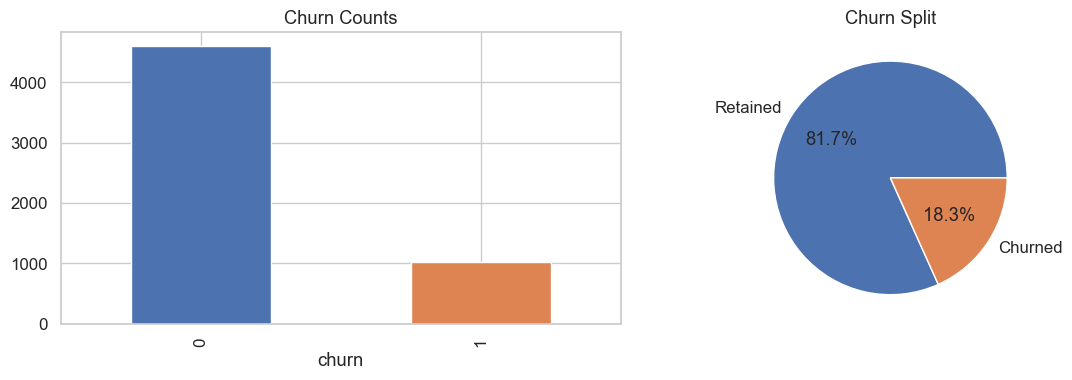

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], title='Churn Counts')
axes[1].pie(df['churn'].value_counts(), labels=['Retained','Churned'], autopct='%1.1f%%', colors=['#4C72B0','#DD8452'])
axes[1].set_title('Churn Split')
plt.tight_layout(); plt.show()

## 3. Feature Distributions

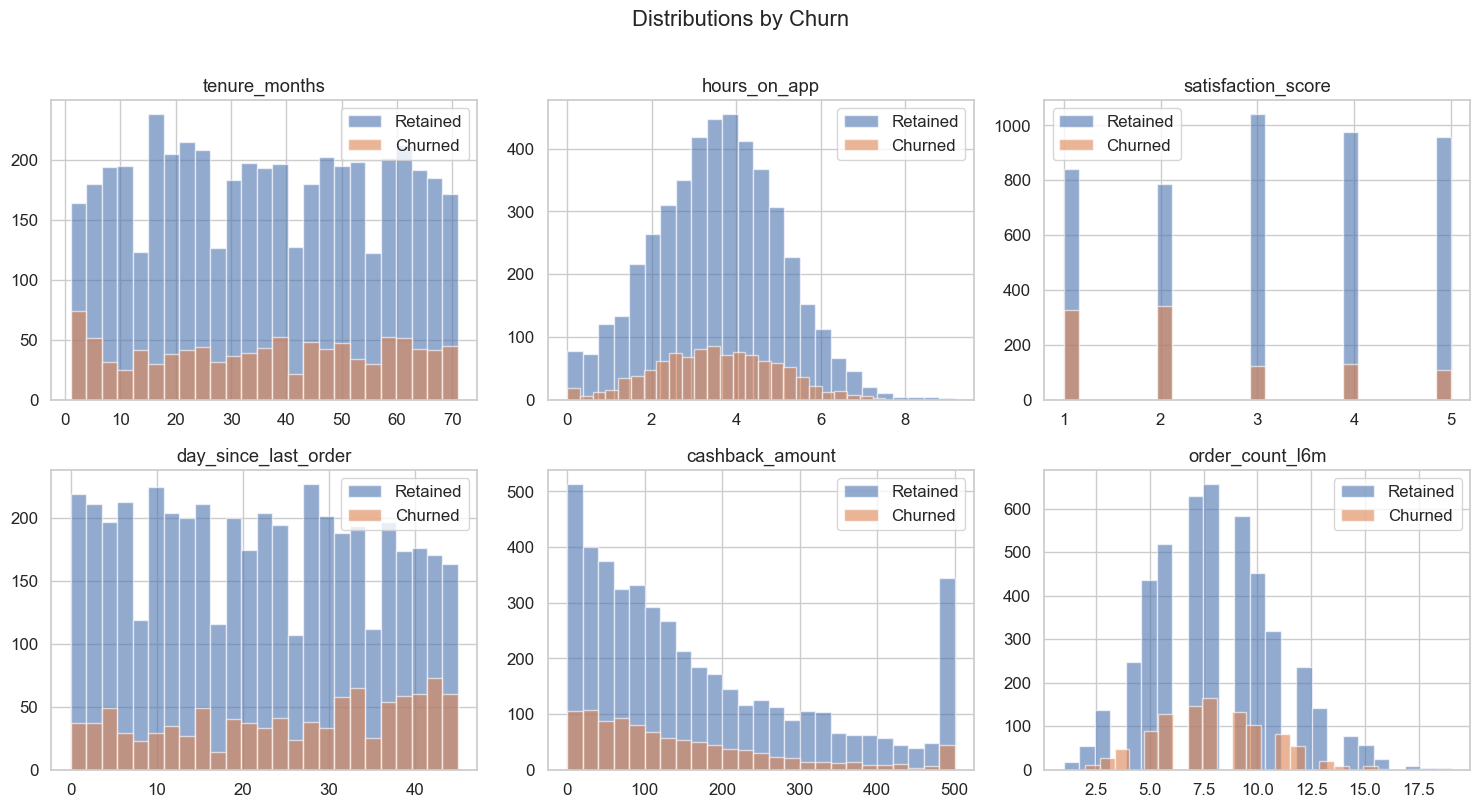

In [7]:
cols = ['tenure_months','hours_on_app','satisfaction_score','day_since_last_order','cashback_amount','order_count_l6m']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols):
    df[df.churn==0][col].hist(ax=ax, alpha=0.6, bins=25, label='Retained', color='#4C72B0')
    df[df.churn==1][col].hist(ax=ax, alpha=0.6, bins=25, label='Churned',  color='#DD8452')
    ax.set_title(col); ax.legend()
plt.suptitle('Distributions by Churn', y=1.01); plt.tight_layout(); plt.show()

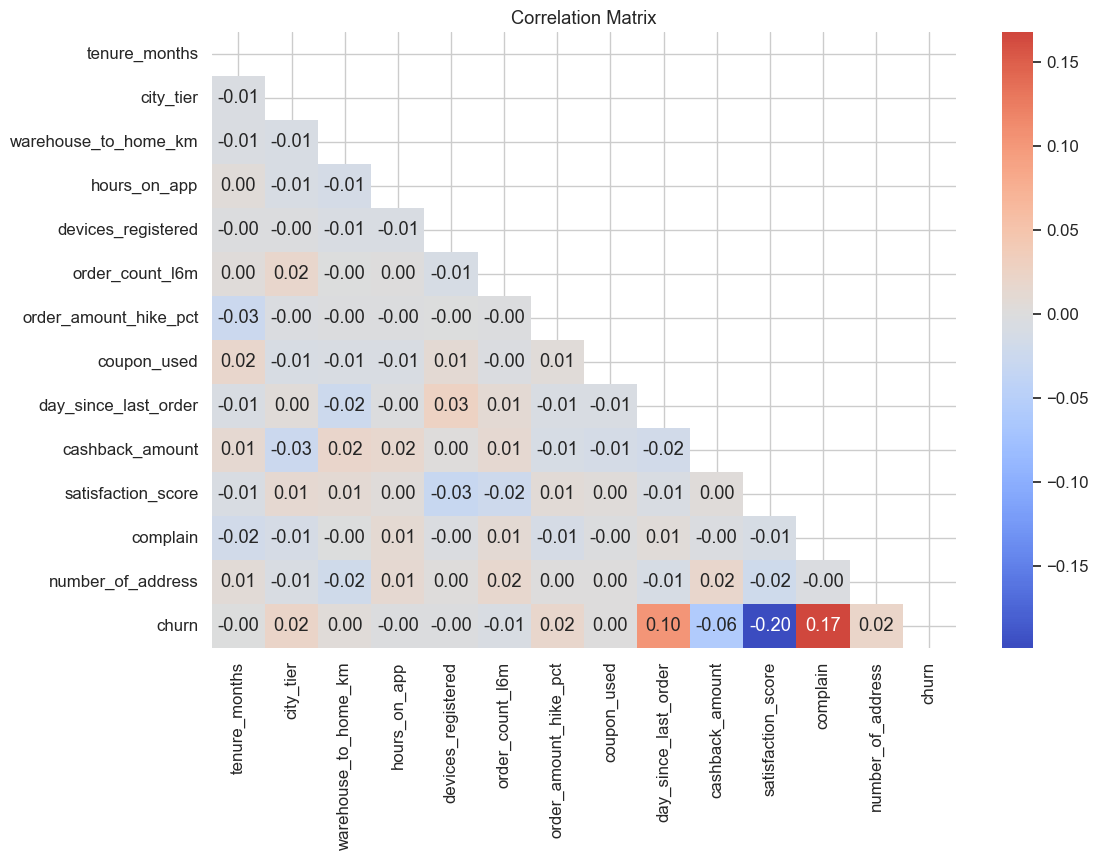

In [8]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title('Correlation Matrix'); plt.show()

## 4. Feature Engineering

In [9]:
df_fe = df.copy()
df_fe['recency_engagement'] = df_fe['day_since_last_order'] / (df_fe['hours_on_app'] + 1)
df_fe['coupon_order_ratio'] = df_fe['coupon_used'] / (df_fe['order_count_l6m'] + 1)
df_fe['high_value_flag']    = (df_fe['cashback_amount'] > df_fe['cashback_amount'].median()).astype(int)
df_fe['multi_device_flag']  = (df_fe['devices_registered'] >= 3).astype(int)
print('Engineered features added')
df_fe[['recency_engagement','coupon_order_ratio','high_value_flag','multi_device_flag']].describe().T

Engineered features added


,count,mean,std,min,25%,50%,75%,max
recency_engagement,5630.0,5.715294,4.840685,0.0,2.341438,4.933798,7.738182,43.0
coupon_order_ratio,5630.0,0.186254,0.184158,0.0,0.076923,0.142857,0.250000,2.5
high_value_flag,5630.0,0.499822,0.500044,0.0,0.000000,0.000000,1.000000,1.0
multi_device_flag,5630.0,0.680995,0.466133,0.0,0.000000,1.000000,1.000000,1.0


## 5. Model Training

In [10]:
num_feats = ['tenure_months','warehouse_to_home_km','hours_on_app','devices_registered',
             'order_count_l6m','order_amount_hike_pct','coupon_used','day_since_last_order',
             'cashback_amount','satisfaction_score','complain','number_of_address','city_tier',
             'recency_engagement','coupon_order_ratio','high_value_flag','multi_device_flag']
cat_feats = ['preferred_login_device','preferred_payment_mode','preferred_order_cat','gender']
X = df_fe.drop(columns=['customer_id','churn'])
y = df_fe['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 4,504 | Test: 1,126


In [11]:
num_pipe = Pipeline([('imp',SimpleImputer(strategy='median')),('scl',StandardScaler())])
cat_pipe = Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
preprocessor = ColumnTransformer([('num',num_pipe,num_feats),('cat',cat_pipe,cat_feats)])
model = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
])
model.fit(X_train, y_train)
print('Training complete')

Training complete


## 6. Evaluation

In [12]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

ROC-AUC: 0.7137
              precision    recall  f1-score   support

    Retained       0.83      0.97      0.89       920
     Churned       0.42      0.09      0.14       206

    accuracy                           0.81      1126
   macro avg       0.62      0.53      0.52      1126
weighted avg       0.75      0.81      0.76      1126



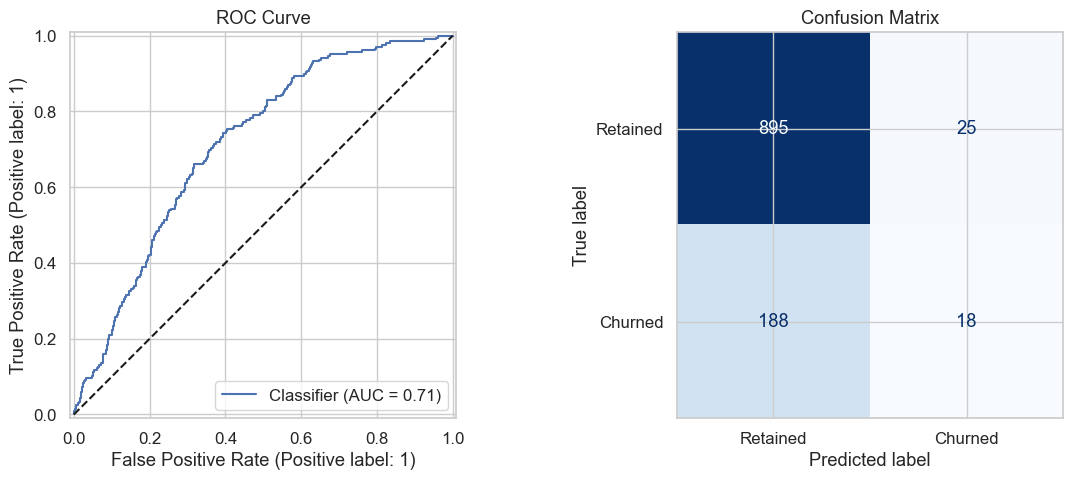

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC Curve')
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred),display_labels=['Retained','Churned']).plot(ax=axes[1],cmap='Blues',colorbar=False)
axes[1].set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

## 7. Feature Importances

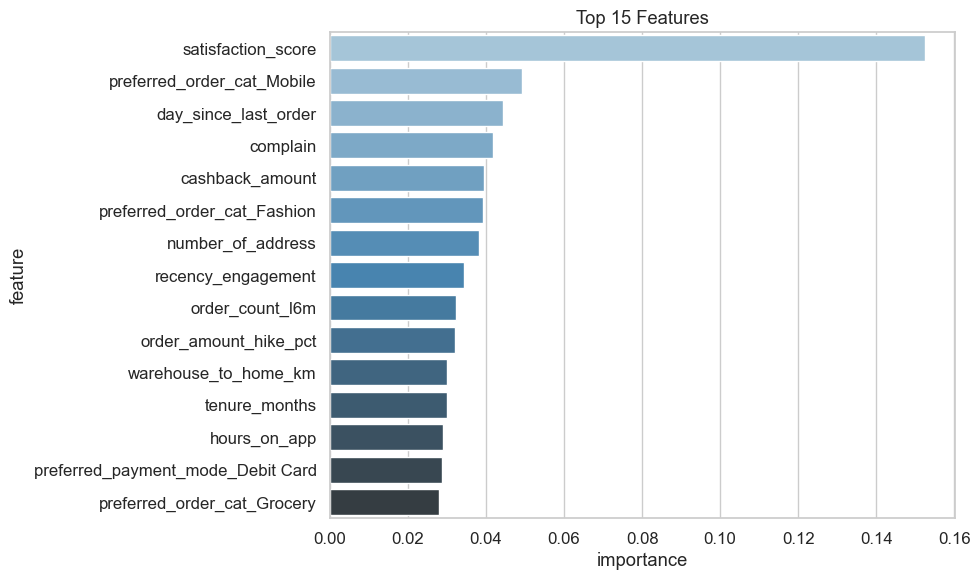

In [14]:
ohe_cats = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(cat_feats).tolist()
all_feats = num_feats + ohe_cats
fi_df = pd.DataFrame({'feature':all_feats,'importance':model.named_steps['rf'].feature_importances_})
fi_df = fi_df.sort_values('importance',ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='Blues_d')
plt.title('Top 15 Features'); plt.tight_layout(); plt.show()

## 8. Risk Tiering & Business Impact

In [15]:
risk = pd.cut(y_proba,[0,0.35,0.65,1.0],labels=['Low','Medium','High'])
summary = pd.DataFrame({'risk':risk,'churn':y_test.values})
print('Risk tier distribution:')
print(summary.risk.value_counts())
print('\nActual churn rate per tier:')
print(summary.groupby('risk')['churn'].mean().map('{:.1%}'.format))

Risk tier distribution:
risk
Low       773
Medium    351
High        2
Name: count, dtype: int64

Actual churn rate per tier:
risk
Low       12.2%
Medium    31.6%
High      50.0%
Name: churn, dtype: object


## 9. Save Model

In [16]:
import os; os.makedirs('../models/artifacts', exist_ok=True)
joblib.dump(model, '../models/artifacts/churn_model_notebook.joblib')
print('Model saved to ../models/artifacts/churn_model_notebook.joblib')

Model saved to ../models/artifacts/churn_model_notebook.joblib
